# 01 — Exploração Inicial do Dataset GitSkills

**Objetivo:** Carregar o dataset GitSkills e realizar uma exploração inicial para entender sua estrutura, volume e conteúdo — com foco em identificar skills relacionadas à **segurança no desenvolvimento com IA**.

**Dataset:** [GitSkills (Zenodo)](https://zenodo.org/records/21875637) · [Mirror HuggingFace](https://huggingface.co/datasets/mvaccargiu/gitskills)  
**Paper:** Destefanis et al. (2027). *GitSkills: A Dataset of Agent Skills on GitHub*. MSR '27. [arXiv:2608.10906](https://arxiv.org/abs/2608.10906)

---

### Pré-requisitos

Antes de executar este notebook, certifique-se de que:
1. O ambiente foi configurado: `make setup`
2. O dataset foi baixado: `make download`
3. O kernel **"Security Skills Analysis"** está selecionado

### Tabelas do Dataset

| Tabela | Registros | Conteúdo |
|--------|-----------|----------|
| `artifacts` | 3.797.117 | Um registro por SKILL.md: repositório, path, hash, texto, front matter |
| `artifact_siblings` | 7.264.865 | Scripts e arquivos de referência junto às skills |
| `repos` | 282.200 | Metadados dos repositórios |
| `mining_runs` | 7 | Log de proveniência |

## 1. Setup e Imports

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de exibição
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 50)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Caminhos dos dados (Parquets baixados via `make download`)
DATA_DIR = Path('../data')

PARQUET_FILES = {
    'artifacts':         DATA_DIR / 'artifacts.parquet',
    'artifact_siblings': DATA_DIR / 'artifact_siblings.parquet',
    'repos':             DATA_DIR / 'repos.parquet',
    'mining_runs':       DATA_DIR / 'mining_runs.parquet',
}

# Verificar se os dados foram baixados
print('Status dos arquivos de dados:')
all_ok = True
for name, path in PARQUET_FILES.items():
    exists = path.exists()
    size = f'{path.stat().st_size / (1024**2):.1f} MB' if exists else '—'
    status = '✅' if exists else '❌'
    print(f'  {status} {name:25s} {size}')
    if not exists:
        all_ok = False

if not all_ok:
    print('\n⚠️  Dados incompletos! Execute: make download')

Status dos arquivos de dados:
  ✅ artifacts                 8092.2 MB
  ✅ artifact_siblings         9575.5 MB
  ✅ repos                     25.8 MB
  ✅ mining_runs               0.0 MB


## 2. Carregamento do Dataset

Carregamos cada tabela a partir dos Parquets locais (baixados via `make download`).

> **Nota sobre memória:** A tabela `artifacts` tem ~3.8M linhas e pode ocupar bastante RAM. Se necessário, use `pd.read_parquet(..., columns=[...])` para selecionar apenas as colunas desejadas.

### 2.1 Tabelas menores — `repos`, `mining_runs`

In [2]:
# Tabelas pequenas — carregam rápido e cabem na memória
df_repos = pd.read_parquet(PARQUET_FILES['repos'])
df_mining = pd.read_parquet(PARQUET_FILES['mining_runs'])

print(f'repos:       {df_repos.shape[0]:>10,} linhas × {df_repos.shape[1]} colunas')
print(f'mining_runs: {df_mining.shape[0]:>10,} linhas × {df_mining.shape[1]} colunas')

repos:          282,200 linhas × 11 colunas
mining_runs:          7 linhas × 7 colunas


### 2.2 Tabela `artifacts` — carregamento parcial

A tabela `artifacts` é grande (~3.8M linhas). Para a exploração inicial, carregamos apenas os metadados (sem o campo `full_text` que é o mais pesado).

In [3]:
# Primeiro: ver quais colunas existem (sem carregar dados)
import pyarrow.parquet as pq

pf = pq.ParquetFile(PARQUET_FILES['artifacts'])
all_columns = pf.schema.names
print(f'Colunas na tabela artifacts ({len(all_columns)}):')
for i, col in enumerate(all_columns):
    print(f'  {i+1:2d}. {col}')

Colunas na tabela artifacts (30):
   1. repo_full_name
   2. path
   3. filename
   4. location_class
   5. file_sha
   6. discovered_at
   7. content
   8. content_fetched
   9. frontmatter_valid
  10. name
  11. description
  12. body_chars
  13. history_fetched
  14. composition_fetched
  15. dedup_primary
  16. first_commit_at
  17. last_commit_at
  18. commit_count
  19. sibling_count
  20. sibling_bytes
  21. has_scripts
  22. has_references
  23. content_sha_ok
  24. composition_truncated
  25. first_commit_author
  26. first_commit_author_type
  27. first_commit_message
  28. last_commit_author
  29. last_commit_author_type
  30. last_commit_message


In [4]:
# Carregar metadados (sem full_text, para economizar memória)
# Ajuste esta lista conforme as colunas reais do dataset
META_COLUMNS = [c for c in all_columns if c not in ('full_text', 'content')]

print(f'Carregando {len(META_COLUMNS)} colunas de metadados...')
df_artifacts_meta = pd.read_parquet(PARQUET_FILES['artifacts'], columns=META_COLUMNS)
print(f'Carregado: {df_artifacts_meta.shape[0]:,} linhas × {df_artifacts_meta.shape[1]} colunas')
print(f'Memória: {df_artifacts_meta.memory_usage(deep=True).sum() / (1024**2):.1f} MB')

Carregando 29 colunas de metadados...
Carregado: 3,797,117 linhas × 29 colunas
Memória: 2360.6 MB


In [5]:
# Carregar uma amostra COM full_text (para análise de conteúdo)
df_artifacts_sample = pd.read_parquet(
    PARQUET_FILES['artifacts'],
    # Carregar todas as colunas, mas apenas as primeiras N linhas
    # Nota: Parquet não garante ordem, então isso é uma amostra arbitrária
).head(5000)

print(f'Amostra com texto: {df_artifacts_sample.shape[0]:,} linhas × {df_artifacts_sample.shape[1]} colunas')
print(f'Memória: {df_artifacts_sample.memory_usage(deep=True).sum() / (1024**2):.1f} MB')

Amostra com texto: 5,000 linhas × 30 colunas
Memória: 2.6 MB


## 3. Exploração da Estrutura

### 3.1 Schema e tipos de dados

In [6]:
print('=== artifacts ===')
display(df_artifacts_sample.dtypes.to_frame('dtype'))
print(f'\nValores nulos:')
null_counts = df_artifacts_sample.isnull().sum()
display(null_counts[null_counts > 0].to_frame('nulos'))

=== artifacts ===


,dtype
repo_full_name,str
path,str
filename,str
location_class,str
file_sha,str
discovered_at,str
content,str
content_fetched,int64
frontmatter_valid,float64
name,str



Valores nulos:


,nulos
content,3368
frontmatter_valid,3368
name,4933
description,4961
body_chars,3368
first_commit_at,4358
last_commit_at,4358
commit_count,4358
sibling_count,3369
sibling_bytes,3369


In [7]:
print('=== repos ===')
display(df_repos.dtypes.to_frame('dtype'))
print(f'\nValores nulos:')
null_counts_repos = df_repos.isnull().sum()
display(null_counts_repos[null_counts_repos > 0].to_frame('nulos'))

=== repos ===


,dtype
full_name,str
owner,str
stars,float64
forks,float64
is_fork,float64
language,str
license,str
description,str
created_at,str
pushed_at,str



Valores nulos:


,nulos
stars,515
forks,515
is_fork,515
language,515
license,515
description,113141
created_at,515
pushed_at,515


In [8]:
print('=== mining_runs (completa) ===')
display(df_mining)

=== mining_runs (completa) ===


,run_id,artifact_type,query,started_at,finished_at,discovered,note
0,1,agent-skills,filename:SKILL.md,2026-07-09T17:26:45.768703+00:00,2026-07-09T18:04:34.751737+00:00,11796,NaN
1,2,agent-skills,filename:SKILL.md,2026-07-09T18:07:39.150068+00:00,2026-07-12T06:54:51.308396+00:00,1328473,NaN
2,3,agent-skills,filename:SKILL.md,2026-07-12T06:59:13.601456+00:00,2026-07-20T22:26:56.553671+00:00,0,closed retroactively: process crashed before finishing (repair-runs)
3,4,agent-skills,filename:SKILL.md,2026-07-13T12:52:52.309967+00:00,2026-07-20T22:26:56.553671+00:00,0,closed retroactively: process crashed before finishing (repair-runs)
4,5,agent-skills,filename:SKILL.md,2026-07-14T18:04:23.050325+00:00,2026-07-20T05:23:31.638481+00:00,1657948,NaN
5,6,agent-skills,filename:SKILL.md,2026-07-20T05:28:44.667482+00:00,2026-07-20T22:26:56.553671+00:00,0,closed retroactively: process crashed before finishing (repair-runs)
6,7,agent-skills,filename:SKILL.md,2026-07-20T07:38:28.581854+00:00,2026-07-20T22:26:56.553671+00:00,0,closed retroactively: process crashed before finishing (repair-runs)


### 3.2 Primeiros registros

In [9]:
print('Primeiros registros — artifacts (amostra):')
display(df_artifacts_sample.head(10))

Primeiros registros — artifacts (amostra):


,repo_full_name,path,filename,location_class,file_sha,discovered_at,content,content_fetched,frontmatter_valid,name,description,body_chars,history_fetched,composition_fetched,dedup_primary,first_commit_at,last_commit_at,commit_count,sibling_count,sibling_bytes,has_scripts,has_references,content_sha_ok,composition_truncated,first_commit_author,first_commit_author_type,first_commit_message,last_commit_author,last_commit_author_type,last_commit_message
0,williamfiset/algorithms,.gemini/SKILL.md,SKILL.md,other,13a96ab46007faee7b417f18c56feef5ff2867c3,2026-07-09T17:26:45.768703+00:00,../.claude/SKILL.md,1,0.0,NaN,NaN,19.0,0,1,1,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,alirezarezvani/claude-skills,.gemini/skills/tc/SKILL.md,SKILL.md,skills-dir,12f4e1a936b32578173e1fba0cffb93d1b6e265a,2026-07-09T17:26:45.768703+00:00,NaN,0,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,lvisei/web-developer-resources,vue/skill.md,skill.md,other,6d30ea2601dd3940e2754aca33116616e211e1aa,2026-07-09T17:26:45.768703+00:00,[]()\n,1,0.0,NaN,NaN,5.0,0,1,1,NaN,NaN,NaN,2.0,0.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,PhongFeng/FFramework,Tools/ReadMe/Skill.md,Skill.md,other,1a8c31c5c234058e160b14fd009cbf5e179cbba7,2026-07-09T17:26:45.768703+00:00,### 技能系统\n\n,1,0.0,NaN,NaN,10.0,0,1,1,NaN,NaN,NaN,18.0,1917167.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,0xNyk/council-of-high-intelligence,skills/council/SKILL.md,SKILL.md,skills-dir,4215faefef7c42813299933e45201ad9c2301681,2026-07-09T17:26:45.768703+00:00,../../SKILL.md,1,0.0,NaN,NaN,14.0,0,1,1,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
5,dandaka/traul,docs/skill.md,skill.md,other,70cf401d94fbd8974bab89093cdf818c81606890,2026-07-09T17:26:45.768703+00:00,../skill.md,1,0.0,NaN,NaN,11.0,0,1,1,NaN,NaN,NaN,19.0,312213.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
6,abelrguezr/hacktricks-skills,skills/mobile-pentesting/android-app-pentesting/in-memory-jni-shellcode-execution/SKILL.MD,SKILL.MD,other,eb1ae458f8ee6e88c072a9989724d7685c56beb1,2026-07-09T17:26:45.768703+00:00,NaN,0,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,comeonzhj/Auto-Redbook-Skills,skills/xhs-note-creator/SKILL.md,SKILL.md,skills-dir,4215faefef7c42813299933e45201ad9c2301681,2026-07-09T17:26:45.768703+00:00,NaN,0,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,win4r/mytest,skill.md,skill.md,other,0cdcf06508c13215a1ef92eb6415fb2467787bfd,2026-07-09T17:26:45.768703+00:00,skill.md\n,1,0.0,NaN,NaN,9.0,0,1,1,NaN,NaN,NaN,26.0,33938632.0,1.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
9,Kernel8901/ai-agent-skills-classification,代码质量与测试/testing/skill.md,skill.md,other,2b31011cf9de6c82d52dc386cd7d1a9be83188c1,2026-07-09T17:26:45.768703+00:00,hey,1,0.0,NaN,NaN,3.0,1,1,1,2026-04-04T15:26:48Z,2026-04-04T15:26:48Z,1.0,1.0,269.0,0.0,0.0,1.0,0.0,64ef02bc11633553,User,feat: initial commit - AI Agent Skills Classification Library with 5552+ skills across 46 categories,64ef02bc11633553,User,feat: initial commit - AI Agent Skills Classification Library with 5552+ skills across 46 categories


In [10]:
print('Primeiros registros — repos:')
display(df_repos.head(10))

Primeiros registros — repos:


,full_name,owner,stars,forks,is_fork,language,license,description,created_at,pushed_at,metadata_fetched
0,williamfiset/algorithms,williamfiset,18673.0,4516.0,0.0,Java,MIT,A collection of algorithms and data structures,2017-03-18T02:50:46Z,2026-06-23T09:33:06Z,1
1,alirezarezvani/claude-skills,alirezarezvani,22655.0,3150.0,0.0,Python,MIT,"345 Claude Code skills & agent skills & plugins (30+ Agents, 70+ custom commands, 330+ skills, customizable referenc...",2025-10-19T04:04:05Z,2026-07-14T07:46:55Z,1
2,lvisei/web-developer-resources,lvisei,46.0,11.0,0.0,,MIT,A list of web full stack resources and summarize.,2018-05-31T02:05:06Z,2023-02-09T16:00:33Z,1
3,PhongFeng/FFramework,PhongFeng,97.0,29.0,0.0,C#,,Unity + AI (Harness)解决Agent可靠性与可持续性，GameFramework + HybridCLR + YooAsset 开发的塔防游戏,2022-08-11T07:39:41Z,2026-07-07T06:48:02Z,1
4,0xNyk/council-of-high-intelligence,0xNyk,3564.0,319.0,0.0,Shell,MIT,"Structured multi-perspective deliberation for hard decisions. Run full councils, focused triads, or duo debates acro...",2026-03-02T08:47:09Z,2026-07-15T20:09:36Z,1
5,dandaka/traul,dandaka,111.0,9.0,0.0,TypeScript,AGPL-3.0,Personal Intelligence Engine — aggregates communication streams into a searchable local index,2026-03-14T19:55:27Z,2026-05-06T16:26:41Z,1
6,abelrguezr/hacktricks-skills,abelrguezr,19.0,7.0,0.0,Python,,A collection of reusable red teaming agent skills derived from Hacktricks created with Qwen3.5-27B-FP8,2026-03-23T14:28:29Z,2026-03-23T14:34:10Z,1
7,comeonzhj/Auto-Redbook-Skills,comeonzhj,1996.0,241.0,0.0,Python,,一个自动撰写小红书笔记，自动生成图片，自动发布的 Skills,2026-01-18T13:51:27Z,2026-04-01T05:19:45Z,1
8,win4r/mytest,win4r,14.0,5.0,0.0,Jupyter Notebook,,AI超元域频道_视频项目文件,2024-07-03T13:51:55Z,2026-02-02T13:27:16Z,1
9,Kernel8901/ai-agent-skills-classification,Kernel8901,4.0,0.0,0.0,Python,MIT,AI Agent Skills Classification Library - A comprehensive collection of categorized AI agent skills for various domai...,2026-04-04T09:23:25Z,2026-04-05T08:43:56Z,1


### 3.3 Estatísticas descritivas

In [11]:
print('=== Estatísticas Descritivas — artifacts (amostra) ===')
display(df_artifacts_sample.describe(include='all').T)

=== Estatísticas Descritivas — artifacts (amostra) ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
repo_full_name,5000,920,muammeryldrm42/OpenTalonss,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
path,5000,3411,src/skills/bundled/verify/SKILL.md,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
filename,5000,5,SKILL.md,4932,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_class,5000,3,skills-dir,3646,NaN,NaN,NaN,NaN,NaN,NaN,NaN
file_sha,5000,1742,64af4f8124bed3a51f19d0ccf086956f761b2ea9,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
discovered_at,5000,1,2026-07-09T17:26:45.768703+00:00,5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
content,1632,1632,../.claude/SKILL.md,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
content_fetched,5000.0,NaN,NaN,NaN,0.3264,0.468942,0.0,0.0,0.0,1.0,1.0
frontmatter_valid,1632.0,NaN,NaN,NaN,0.021446,0.14491,0.0,0.0,0.0,0.0,1.0
name,67,63,test,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print('=== Estatísticas Descritivas — repos ===')
display(df_repos.describe(include='all').T)

## 4. Distribuições Básicas

Distribuição de location_class (dataset completo):


location_class
skills-dir    2102053
other         1321412
canonical      373652
Name: count, dtype: int64

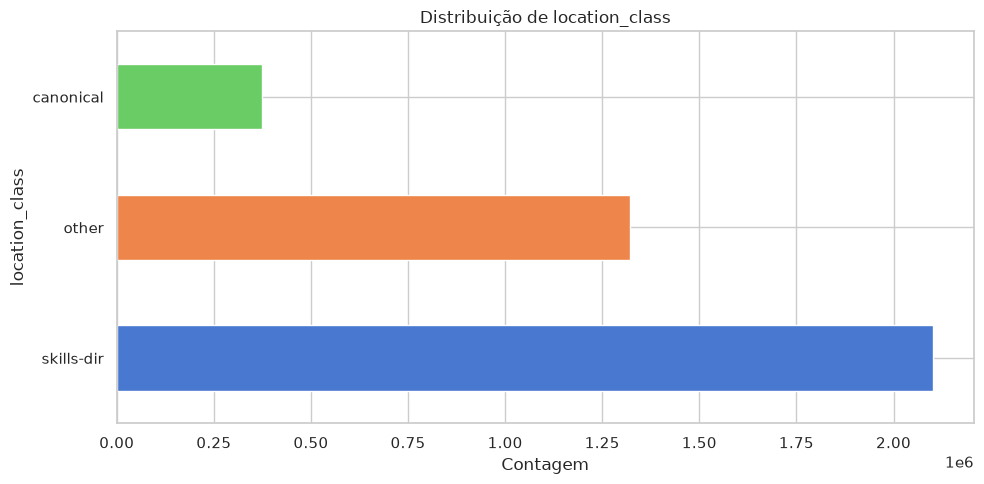

In [12]:
# Distribuição de location_class (indica onde o SKILL.md está no repositório)
if 'location_class' in df_artifacts_meta.columns:
    loc_dist = df_artifacts_meta['location_class'].value_counts()
    print('Distribuição de location_class (dataset completo):')
    display(loc_dist)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    loc_dist.plot(kind='barh', ax=ax, color=sns.color_palette('muted'))
    ax.set_title('Distribuição de location_class')
    ax.set_xlabel('Contagem')
    plt.tight_layout()
    plt.show()

Top 20 linguagens nos repositórios:


language
Python              71801
TypeScript          67104
                    29601
JavaScript          23938
Shell               19780
HTML                12187
Rust                 8371
Go                   8094
C#                   5168
Java                 3172
PHP                  3115
PowerShell           2136
Dart                 2047
C++                  2022
Swift                1947
Kotlin               1940
Jupyter Notebook     1717
Lua                  1642
Vue                  1490
CSS                  1242
Name: count, dtype: int64

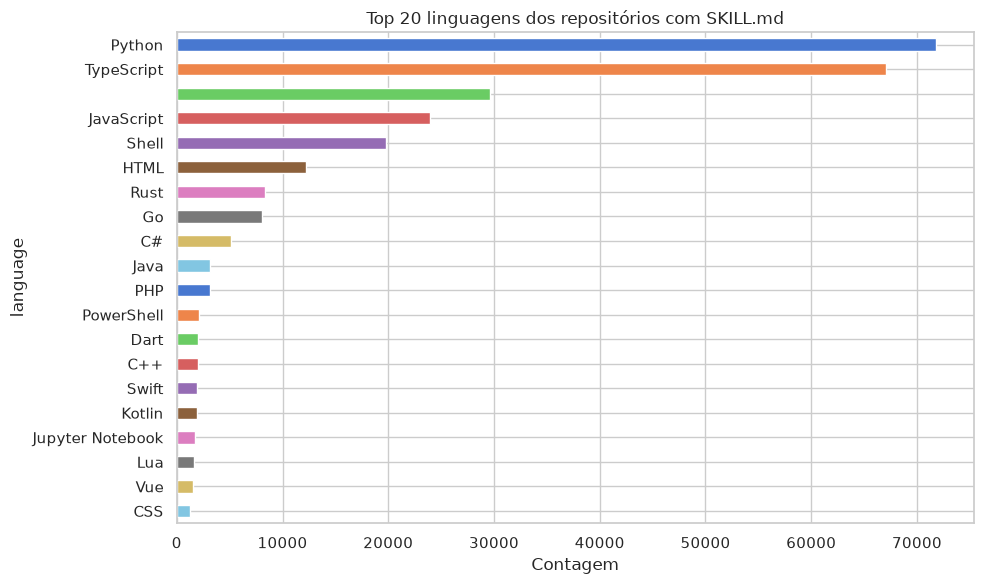

In [13]:
# Distribuição de linguagens dos repositórios
if 'language' in df_repos.columns:
    lang_dist = df_repos['language'].value_counts().head(20)
    print('Top 20 linguagens nos repositórios:')
    display(lang_dist)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    lang_dist.plot(kind='barh', ax=ax, color=sns.color_palette('muted'))
    ax.set_title('Top 20 linguagens dos repositórios com SKILL.md')
    ax.set_xlabel('Contagem')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

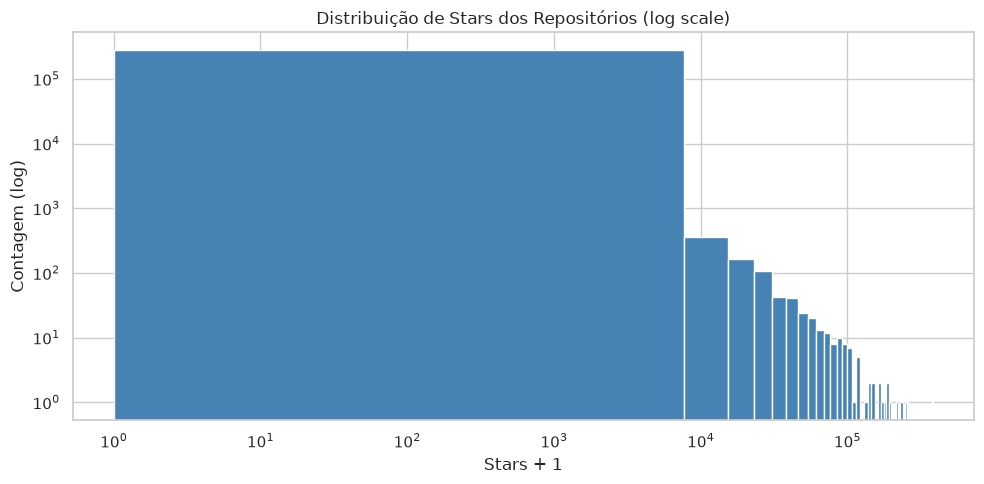


Estatísticas de stars:


count    281685.000000
mean        122.150803
std        2405.834728
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max      383040.000000
Name: stars, dtype: float64

In [14]:
# Distribuição de estrelas (log scale)
if 'stargazers_count' in df_repos.columns:
    star_col = 'stargazers_count'
elif 'stars' in df_repos.columns:
    star_col = 'stars'
else:
    star_col = None
    print('Coluna de stars não encontrada. Colunas disponíveis:', list(df_repos.columns))

if star_col:
    fig, ax = plt.subplots(figsize=(10, 5))
    df_repos[star_col].clip(lower=0).apply(lambda x: x + 1).hist(
        bins=50, ax=ax, log=True, color='steelblue', edgecolor='white'
    )
    ax.set_title('Distribuição de Stars dos Repositórios (log scale)')
    ax.set_xlabel('Stars + 1')
    ax.set_ylabel('Contagem (log)')
    ax.set_xscale('log')
    plt.tight_layout()
    plt.show()
    
    print(f'\nEstatísticas de stars:')
    display(df_repos[star_col].describe())

## 5. Conteúdo Textual das Skills

Verificar os campos de texto disponíveis e exemplos de conteúdo.

In [15]:
# Identificar colunas textuais relevantes
text_cols = [c for c in df_artifacts_sample.columns if any(
    kw in c.lower() for kw in ['text', 'content', 'body', 'front_matter', 'description', 'name']
)]
print(f'Colunas com potencial textual: {text_cols}')

# Mostrar exemplos de conteúdo
for col in text_cols:
    non_null = df_artifacts_sample[col].dropna()
    if len(non_null) > 0:
        avg_len = non_null.astype(str).str.len().mean()
        print(f'\n--- {col} ({len(non_null)} não-nulos, tamanho médio: {avg_len:.0f} chars) ---')
        print(str(non_null.iloc[0])[:500])

Colunas com potencial textual: ['repo_full_name', 'filename', 'content', 'content_fetched', 'name', 'description', 'body_chars', 'content_sha_ok']

--- repo_full_name (5000 não-nulos, tamanho médio: 26 chars) ---
williamfiset/algorithms

--- filename (5000 não-nulos, tamanho médio: 8 chars) ---
SKILL.md

--- content (1632 não-nulos, tamanho médio: 36 chars) ---
../.claude/SKILL.md

--- content_fetched (5000 não-nulos, tamanho médio: 1 chars) ---
1

--- name (67 não-nulos, tamanho médio: 8 chars) ---
web-search-exa

--- description (39 não-nulos, tamanho médio: 6 chars) ---
MO

--- body_chars (1632 não-nulos, tamanho médio: 4 chars) ---
19.0

--- content_sha_ok (1632 não-nulos, tamanho médio: 3 chars) ---
1.0


In [16]:
# Identificar a coluna principal de texto
TEXT_COL = None
for candidate in ['full_text', 'content', 'body', 'text']:
    if candidate in df_artifacts_sample.columns:
        TEXT_COL = candidate
        break

if TEXT_COL is None:
    # Fallback: coluna de objeto com maior comprimento médio
    for col in df_artifacts_sample.select_dtypes(include='object').columns:
        avg_len = df_artifacts_sample[col].dropna().astype(str).str.len().mean()
        if avg_len > 200:
            TEXT_COL = col
            break

print(f'Coluna de texto principal: {TEXT_COL}')

if TEXT_COL:
    # Exemplo completo de um SKILL.md
    example = df_artifacts_sample[TEXT_COL].dropna().iloc[0]
    print(f'\n=== Exemplo de skill (primeiros 2000 chars) ===\n')
    print(example[:2000])

Coluna de texto principal: content

=== Exemplo de skill (primeiros 2000 chars) ===

../.claude/SKILL.md


## 6. Busca Inicial por Termos de Segurança

Busca por termos relacionados à segurança nos textos das skills para uma primeira noção de prevalência na amostra.

In [17]:
# Termos de busca relacionados à segurança
SECURITY_KEYWORDS = [
    # Termos gerais de segurança
    'security', 'secure', 'vulnerability', 'exploit',
    'authentication', 'authorization', 'auth',
    'encryption', 'encrypt', 'decrypt',
    # Ataques e vulnerabilidades
    'injection', 'xss', 'csrf', 'sql injection',
    'sanitize', 'sanitization', 'validate', 'validation',
    # Supply chain / dependências
    'dependency', 'supply chain', 'audit',
    # Secrets / credentials
    'secret', 'credential', 'token', 'api key', 'password',
    # Segurança em IA/LLM
    'prompt injection', 'jailbreak', 'guardrail',
    'safety', 'harmful', 'malicious',
    # Práticas e frameworks
    'owasp', 'cve', 'penetration', 'pentest',
    'firewall', 'sandbox', 'permission',
]

print(f'Total de keywords de segurança: {len(SECURITY_KEYWORDS)}')

Total de keywords de segurança: 39


Prevalência de keywords na amostra (5000 registros):



,keyword,count
20,audit,24
6,auth,10
0,security,7
16,validate,5
18,dependency,2
1,secure,2
17,validation,1
21,secret,1
37,sandbox,1
29,safety,1


/tmp/ipykernel_61393/3383223434.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_kw, y='keyword', x='count', ax=ax, palette='YlOrRd_r')


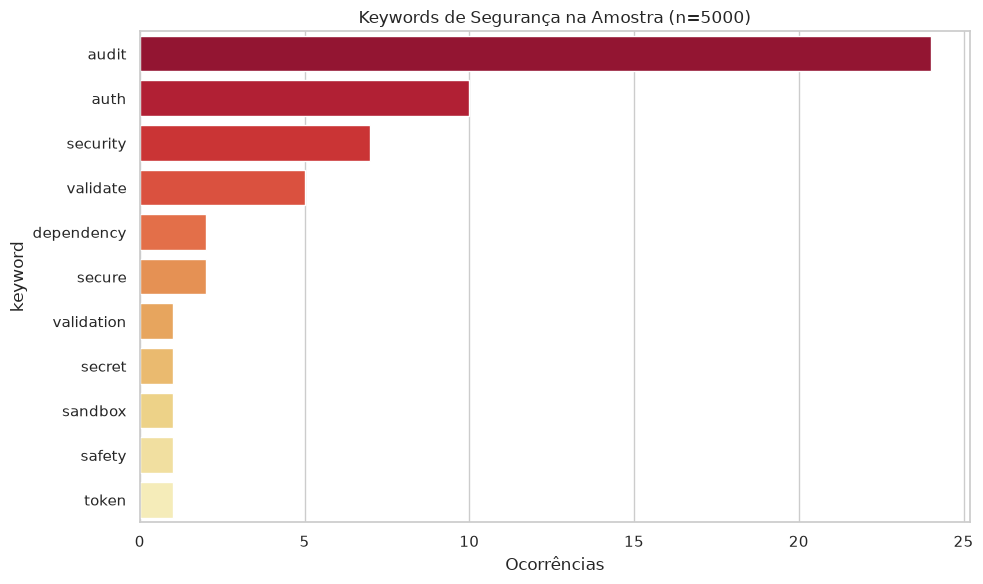

In [18]:
if TEXT_COL:
    # Criar coluna de busca (lowercase)
    search_text = df_artifacts_sample[TEXT_COL].fillna('').str.lower()
    
    # Contar ocorrências de cada keyword
    keyword_counts = {}
    for kw in SECURITY_KEYWORDS:
        mask = search_text.str.contains(kw, case=False, na=False)
        keyword_counts[kw] = mask.sum()
    
    keyword_df = pd.DataFrame(
        list(keyword_counts.items()), 
        columns=['keyword', 'count']
    ).sort_values('count', ascending=False)
    
    print(f'Prevalência de keywords na amostra ({len(df_artifacts_sample)} registros):\n')
    display(keyword_df[keyword_df['count'] > 0])
    
    # Visualização
    top_kw = keyword_df[keyword_df['count'] > 0].head(20)
    if len(top_kw) > 0:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=top_kw, y='keyword', x='count', ax=ax, palette='YlOrRd_r')
        ax.set_title(f'Keywords de Segurança na Amostra (n={len(df_artifacts_sample)})')
        ax.set_xlabel('Ocorrências')
        plt.tight_layout()
        plt.show()
else:
    print('⚠️  Sem coluna de texto para busca.')

In [19]:
if TEXT_COL:
    # Quantas skills mencionam pelo menos um termo de segurança?
    any_security = search_text.apply(
        lambda t: any(kw in t for kw in SECURITY_KEYWORDS)
    )
    
    n_security = any_security.sum()
    pct_security = any_security.mean()
    
    print(f'Skills com ao menos 1 termo de segurança:')
    print(f'  {n_security} / {len(df_artifacts_sample)} ({pct_security:.1%})')

Skills com ao menos 1 termo de segurança:
  53 / 5000 (1.1%)


In [20]:
# Exibir exemplos de skills que mencionam segurança
if TEXT_COL and n_security > 0:
    security_skills = df_artifacts_sample[any_security].copy()
    
    # Identificar colunas para display
    display_cols = [c for c in [
        'repo', 'repository', 'path', 'name', 'description', 'location_class'
    ] if c in security_skills.columns]
    
    print(f'=== Exemplos de Skills com Termos de Segurança ({len(security_skills)} encontradas) ===\n')
    
    for idx, (_, row) in enumerate(security_skills.head(5).iterrows()):
        print(f'--- Exemplo {idx + 1} ---')
        for col in display_cols:
            val = str(row[col])[:200] if pd.notna(row[col]) else 'N/A'
            print(f'  {col}: {val}')
        # Trecho do texto
        text_preview = str(row[TEXT_COL])[:500] if pd.notna(row[TEXT_COL]) else 'N/A'
        print(f'  {TEXT_COL} (trecho): {text_preview}')
        print()

=== Exemplos de Skills com Termos de Segurança (53 encontradas) ===

--- Exemplo 1 ---
  path: plugins/assume-persona/skills/audit/SKILL.md
  name: N/A
  description: N/A
  location_class: skills-dir
  content (trecho): audit.md

--- Exemplo 2 ---
  path: scripts/fixtures/eval-harness/negative/.opencode/skills/docs-validation/SKILL.md
  name: N/A
  description: N/A
  location_class: skills-dir
  content (trecho): # docs-validation


--- Exemplo 3 ---
  path: .claude/skills/audit/SKILL.md
  name: N/A
  description: N/A
  location_class: canonical
  content (trecho): ../../../skills/audit/SKILL.md

--- Exemplo 4 ---
  path: .agents/skills/validate-skills/SKILL.md
  name: N/A
  description: N/A
  location_class: skills-dir
  content (trecho): ../../tools/validate-skills.md

--- Exemplo 5 ---
  path: .agents/quran/skills/seo-audit/SKILL.md
  name: N/A
  description: N/A
  location_class: skills-dir
  content (trecho): ../../../skills/seo-audit/SKILL.md



## 7. Próximos Passos

Após esta exploração inicial, as próximas etapas incluem:

1. **Filtragem em escala:** Aplicar os filtros de segurança ao dataset completo (não apenas à amostra)
2. **Taxonomia de segurança:** Categorizar os tipos de skills de segurança encontradas
3. **Análise de lacunas:** Identificar aspectos de segurança pouco ou não cobertos pelas skills
4. **Qualidade das instruções:** Avaliar se as skills de segurança contêm instruções corretas
5. **Relação com repositórios:** Cruzar com metadados dos repos (linguagem, popularidade, licença)
6. **Análise de supply-chain:** Investigar se skills copiadas introduzem comandos ou acessos maliciosos